In [1]:
from mdcrow import MDCrow
from langchain.callbacks import get_openai_callback
from datetime import datetime
import os 
import traceback

In [2]:
import sys
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '../'))
sys.path.append(parent_dir)
from robustness_prompts import get_prompt # noqa: E402

prompt_4_natural = get_prompt("natural", 4)

prompt_4_natural

'Simulate 1LYZ for 1ps at 300 K. Report the secondary structure assignments of the downloaded PDB structure, and compute the RMSD of the simulation.'

In [3]:
llm_model = "gpt-4-1106-preview"
tools = "all"

In [4]:
agent = MDCrow(
    agent_type="Structured", 
    model=llm_model, 
    top_k_tools=tools, 
    use_memory=False,
    streaming=False,
    verbose=True,
)
with get_openai_callback() as cb:
    chat_start = datetime.now()
    try:
        response = agent.run(prompt_4_natural, callbacks=[cb])
        print(response)
    except Exception as e:
        exc_type, exc_value, exc_traceback = sys.exc_info()
        print(f'{type(e).__name__}:{e}')
        print("".join(traceback.format_exception(exc_type, exc_value, exc_traceback)))
    chat_end = datetime.now()
    total_runtime = (chat_end - chat_start).total_seconds()
    print(cb)
    print(f"Total runtime: {total_runtime:.2f}s")



> Entering new AgentExecutor chain...


Thought: To accomplish the task, I need to first download the PDB structure of 1LYZ. Then, I will set up and run a simulation for 1 picosecond at 300 K. After the simulation, I will report the secondary structure assignments of the downloaded PDB structure and compute the RMSD of the simulation. I will start by downloading the PDB structure of 1LYZ using the PDBFileDownloader tool.

Action:
```
{
    "action": "PDBFileDownloader",
    "action_input": {
        "query": "1LYZ"
    }
}
```PDB file found with this ID: 1LYZ

Observation: Succeeded. Downloaded the PDB file:1LYZ_213605
Thought:

Now that I have the PDB file for 1LYZ, the next step is to set up and run a molecular dynamics simulation for 1 picosecond at 300 K. I will use the SetUpandRunFunction tool to perform this task. I need to specify the PDB ID, the forcefield files, and the simulation parameters including temperature and duration.

Action:
```
{
    "action": "SetUpandRunFunction",
    "action_input": {
        "pdb_id": "1LYZ_213605",
        "forcefield_files": ["amber99sbildn.xml", "tip3p.xml"],
        "system_params": {
            "nonbondedMethod": "PME",
            "nonbondedCutoff": "1 * nanometers",
            "constraints": "HBonds",
            "rigidWater": true,
            "solvate": true
        },
        "integrator_params": {
            "integrator_type": "LangevinMiddle",
            "Temperature": "300 * kelvin",
            "Friction": "1.0 / picoseconds",
            "Timestep": "0.001 * picoseconds"
        },
        "simulation_params": {
            "Ensemble": "NVT",
       

The previous attempt to run the simulation failed because the constraintTolerance was not specified. Since rigidWater is set to True, I need to include the constraintTolerance in the system parameters. I will correct this and try to run the simulation again using the SetUpandRunFunction tool.

Action:
```
{
    "action": "SetUpandRunFunction",
    "action_input": {
        "pdb_id": "1LYZ_213605",
        "forcefield_files": ["amber99sbildn.xml", "tip3p.xml"],
        "system_params": {
            "nonbondedMethod": "PME",
            "nonbondedCutoff": "1 * nanometers",
            "constraints": "HBonds",
            "rigidWater": true,
            "constraintTolerance": 0.00001,
            "solvate": true
        },
        "integrator_params": {
            "integrator_type": "LangevinMiddle",
            "Temperature": "300 * kelvin",
            "Friction": "1.0 / picoseconds",
            "Timestep": "0.001 * picoseconds"
        },
        "simulation_params": {
            "

About to create system...
Attempts at creating system: 0/3
Error adding solvent ValueError – No template found for residue 1 (LYS).  The set of atoms is similar to HID, but it is missing 8 atoms.  For more information, see https://github.com/openmm/openmm/wiki/Frequently-Asked-Questions#template
Residue code: LYS
Residue code not in solvent list. Adding forcefield                         not supported.

Observation: Failed. No template found for residue 1 (LYS).  The set of atoms is similar to HID, but it is missing 8 atoms.  For more information, see https://github.com/openmm/openmm/wiki/Frequently-Asked-Questions#templateThis were the inputs {'pdb_id': '1LYZ_213605', 'forcefield_files': ['amber99sbildn.xml', 'tip3p.xml'], 'system_params': {'nonbondedMethod': 'PME', 'nonbondedCutoff': '1 * nanometers', 'constraints': 'HBonds', 'rigidWater': True, 'constraintTolerance': 1e-05, 'solvate': True}, 'integrator_params': {'integrator_type': 'LangevinMiddle', 'Temperature': '300 * kelvin', 'F

...


Observation: {'residues in helix': 50, 'residues in strand': 16, 'residues in coil': 63, 'residues not assigned, not a protein residue': 6791}
Thought:

The secondary structure assignment for the initial frame of the 1LYZ protein simulation indicates that there are 50 residues in a helix, 16 residues in a strand, and 63 residues in a coil. There are also 6791 residues not assigned, which are likely not protein residues but other atoms or molecules in the system. Now, I need to compute the RMSD of the simulation. To do this, I will use the ComputeRMSD tool with the trajectory file and the initial topology file, setting the reference to the first frame of the simulation.

Action:
```
{
    "action": "ComputeRMSD",
    "action_input": {
        "top_id": "top_sim0_213635",
        "traj_id": "rec0_213639",
        "ref_top_id": "top_sim0_213635",
        "ref_traj_id": "rec0_213639",
        "select": "protein",
        "mol_name": "1LYZ"
    }
}
```

Calculating RMSD...
Data saved to /gpfs/fs2/scratch/qcampbe2/repos/MDCrow/ckpt/ckpt_9/records/rmsd_1LYZ.csv


Plot saved to /gpfs/fs2/scratch/qcampbe2/repos/MDCrow/ckpt/ckpt_9/figures/FIG_rmsd_1LYZ_20251222_215005.png

Observation: Succeeded. RMSD calculated and saved to csv with file ID rmsd_1LYZ. Plot saved with plot ID fig0_215005. 
Thought:

Final Answer: The molecular dynamics simulation of the protein 1LYZ for 1 picosecond at 300 K has been successfully completed. The secondary structure assignments for the initial frame of the simulation are as follows: 50 residues in a helix, 16 residues in a strand, and 63 residues in a coil. The RMSD of the simulation has been calculated and the results are saved in a CSV file with the file ID rmsd_1LYZ. A plot of the RMSD over the course of the simulation has also been saved with the plot ID fig0_215005.

> Finished chain.
({'input': '\n    You are an expert molecular dynamics scientist, and\n    your task is to respond to the question or\n    solve the problem to the best of your ability using\n    the provided tools.\n\n    You can only respond with a single complete\n    \'Thought, Action, Action Input\' format\n    OR a single \'Final Answer\' format.\n\n    Complete format:\n    Thought: (reflect on your progress and decide what to do next)\n    Action:\n    ```\n    {\n       

In [3]:
registry = agent.path_registry
print(registry.list_path_names_and_descriptions().replace(",", "\n"))

Files found in registry: 1LYZ_213605: PDB file downloaded from RSCB
 PDBFile ID: 1LYZ_213605
 1LYZ_213626: Cleaned File:  Removed Heterogens
 and Water Removed.  Replaced Nonstandard Residues. Added Hydrogens at pH 7.0. Missing Atoms added and nonstandard residues replaced. 
 top_sim0_213635: Initial positions for simulation sim0_213635
 sim0_213635: Basic Simulation of Protein 1LYZ_213626
 rec0_213639: Simulation trajectory for protein 1LYZ_213626 and simulation sim0_213635
 rec1_213639: Simulation state log for protein 1LYZ_213626 and simulation sim0_213635
 rec2_213639: Simulation pdb frames for protein 1LYZ_213626 and simulation sim0_213635
 rec0_214957: dssp values for trajectory with id: rec0_213639
 rmsd_1LYZ: RMSD for 1LYZ
 fig0_215005: RMSD plot for 1LYZ


In [4]:
# make sure pdb was downloaded
assert os.path.exists(registry.get_mapped_path("1LYZ_213605"))

In [5]:
# make sure dssp was computed correctly
from mdcrow.tools.base_tools import ComputeDSSP

dssp = ComputeDSSP(registry)
dssp._run(traj_file= "1LYZ_213605", target_frames="first")

"{'residues in helix': 50, 'residues in strand': 14, 'residues in coil': 65, 'residues not assigned, not a protein residue': 101}"

In [6]:
# make sure trajectory and topology exist
traj_path = registry.get_mapped_path("rec0_213639")
top_path = registry.get_mapped_path("top_sim0_213635")

assert os.path.exists(traj_path)
assert os.path.exists(top_path)

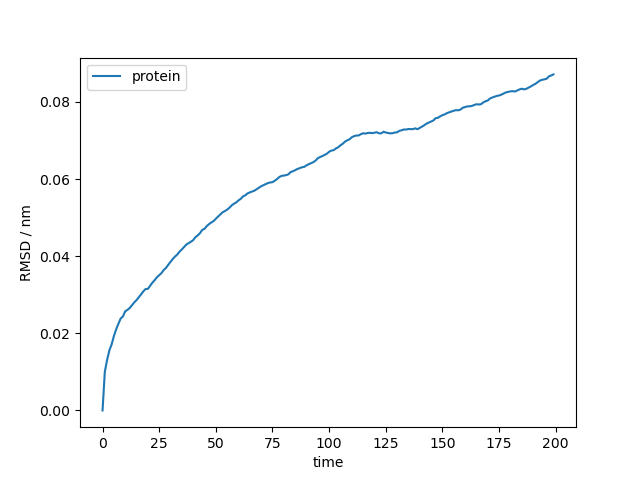

In [7]:
# make sure rmsd plot was generated
from IPython.display import Image
Image(filename=registry.get_mapped_path('fig0_215005'))

In [11]:
#verify the total cost
def calculate_llm_cost(input_tokens, output_tokens, model):
    pricing_2024 = {
        "gpt-4-1106-preview": {"input": 10/1e6, "output": 30/1e6},
        "gpt-3.5-turbo-0125": {"input": 0.5/1e6, "output": 1.5/1e6},
        "gpt-4-turbo-2024-04-09": {"input": 10/1e6, "output": 30/1e6},
        "gpt-4o-2024-08-06": {"input": 5/1e6, "output": 15/1e6},
        "llama-v3p1-70b-instruct": {"input": 0.9/1e6, "output": 0.9/1e6},
        "llama-v3p1-405b-instruct": {"input": 3/1e6, "output": 3/1e6},
        "claude-3-opus": {"input": 15/1e6, "output": 75/1e6},
        "claude-3.5-sonnet": {"input": 3/1e6, "output": 15/1e6},
    }
    pricing_2025 = {
        "gpt-4-1106-preview": {"input": 10/1e6, "output": 30/1e6},
        "gpt-3.5-turbo-0125": {"input": 0.5/1e6, "output": 1.5/1e6},
        "gpt-4-turbo-2024-04-09": {"input": 10/1e6, "output": 30/1e6},
        "gpt-4o-2024-08-06": {"input": 2.5/1e6, "output": 10/1e6},
        "llama-v3p1-70b-instruct": {"input": 0.9/1e6, "output": 0.9/1e6},
        "llama-v3p1-405b-instruct": {"input": 3/1e6, "output": 3/1e6},
    }
    
    prices = pricing_2025[model]
    cost = (input_tokens * prices["input"]) + (output_tokens * prices["output"])
    return round(cost, 6)

llm_cost = calculate_llm_cost(cb.prompt_tokens, cb.completion_tokens, agent.llm.model_name)
print('Input tokens:',cb.prompt_tokens)
print('Output tokens:',cb.completion_tokens)
print('LLM costs: $',llm_cost)

Input tokens: 69744
Output tokens: 1669
LLM costs: $ 0.74751
